# 📉 Telecom Customer Churn Prediction
**Level:** Advanced · **Tools:** Python, Pandas, Scikit-learn, Matplotlib/Seaborn

**Business problem:** a telecom company loses about 1 in 4 customers. The aim is to predict **which customers are likely to churn** so the retention team can step in early, and to understand **why** they leave.

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d): 7,043 customers, 21 features (demographics, services, contract, billing).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("data/telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data cleaning

In [2]:
print(df.shape); print(df.dtypes.value_counts())
# TotalCharges is stored as text; 11 new customers (tenure = 0) have a blank value
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges:", df.TotalCharges.isna().sum(), "| their tenure:", df.loc[df.TotalCharges.isna(),"tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df = df.drop(columns="customerID")
print(f"Churn rate: {df.Churn.mean():.1%}")

(7043, 21)
str        18
int64       2
float64     1
Name: count, dtype: int64
Blank TotalCharges: 11 | their tenure: [0]
Churn rate: 26.5%


## 2. Exploratory analysis: who churns?

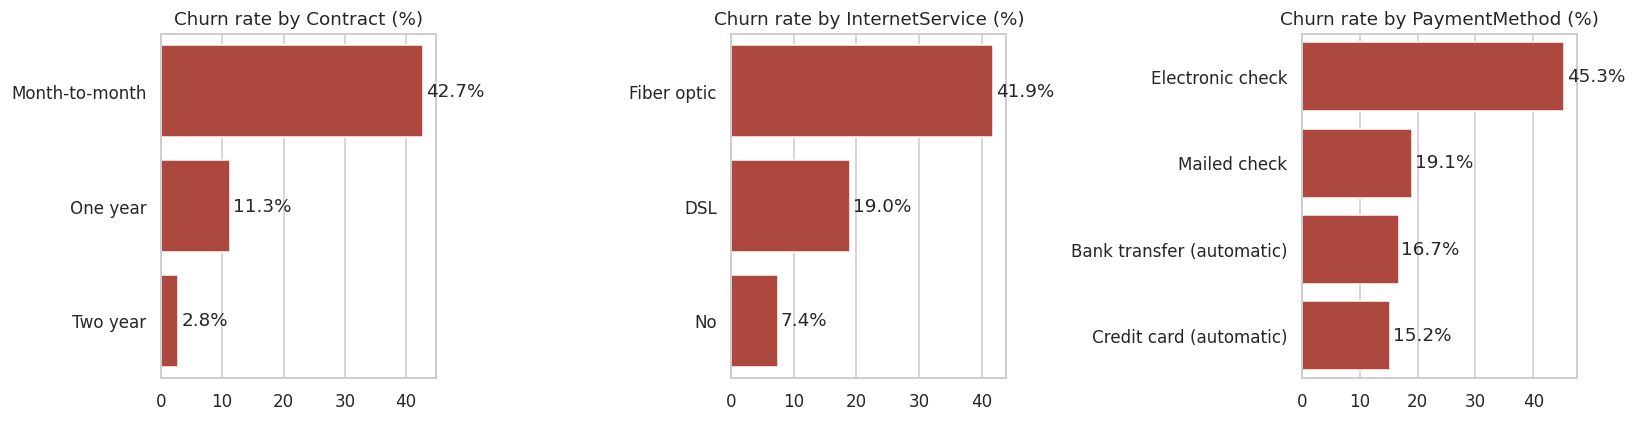

In [3]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, ["Contract","InternetService","PaymentMethod"]):
    r = df.groupby(col).Churn.mean().sort_values(ascending=False)*100
    sns.barplot(x=r.values, y=r.index, ax=ax, color="#C0392B"); ax.set_title(f"Churn rate by {col} (%)"); ax.set_xlabel(""); ax.set_ylabel("")
    for i,v in enumerate(r.values): ax.text(v+0.5, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.savefig("images/churn_by_category.png", bbox_inches="tight"); plt.show()

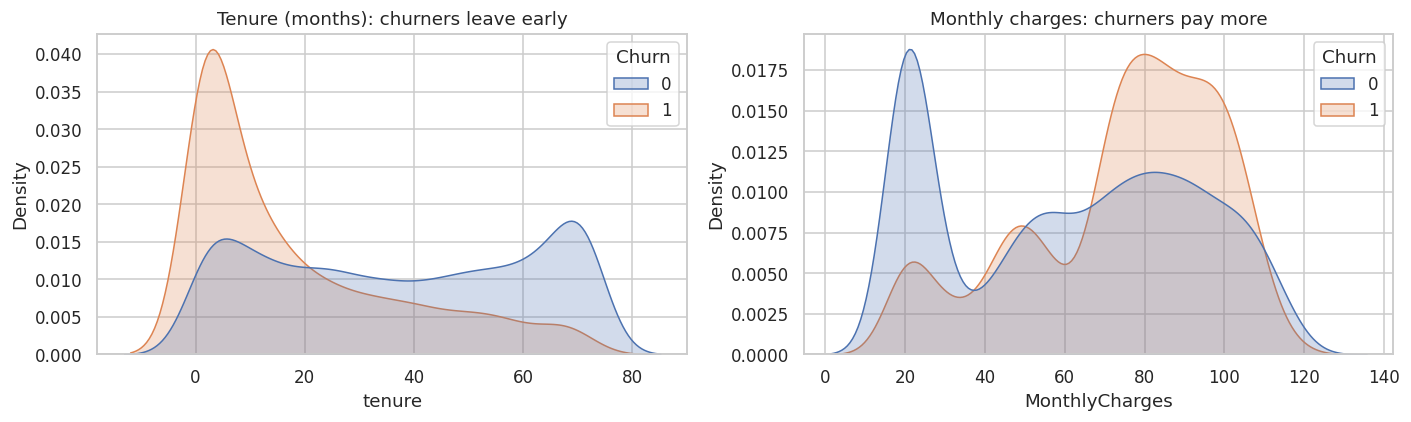

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


In [4]:
fig, axes = plt.subplots(1,2, figsize=(13,4))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, ax=axes[0]); axes[0].set_title("Tenure (months): churners leave early")
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", common_norm=False, fill=True, ax=axes[1]); axes[1].set_title("Monthly charges: churners pay more")
plt.tight_layout(); plt.savefig("images/tenure_charges.png", bbox_inches="tight"); plt.show()
df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].median()

In [5]:
# Churn by tenure band
df["TenureBand"] = pd.cut(df.tenure, [-1,12,24,48,72], labels=["0-12m","13-24m","25-48m","49-72m"])
df.groupby("TenureBand", observed=True).Churn.agg(["mean","count"]).rename(columns={"mean":"churn_rate"}).style.format({"churn_rate":"{:.1%}"})

,churn_rate,count
TenureBand,,
0-12m,47.4%,2186
13-24m,28.7%,1024
25-48m,20.4%,1594
49-72m,9.5%,2239


## 3. Feature engineering & preprocessing

In [6]:
df["NumServices"] = (df[["PhoneService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]] == "Yes").sum(axis=1)
df["AvgMonthlySpend"] = np.where(df.tenure > 0, df.TotalCharges / df.tenure.replace(0,1), df.MonthlyCharges)
X = df.drop(columns=["Churn","TenureBand"]); y = df.Churn
num = ["tenure","MonthlyCharges","TotalCharges","NumServices","AvgMonthlySpend","SeniorCitizen"]
cat = [c for c in X.columns if c not in num]
pre = ColumnTransformer([("num", StandardScaler(), num), ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(5634, 21) (1409, 21)


## 4. Model training & comparison
Classes are imbalanced (≈26% churn), so the models use `class_weight='balanced'` where it applies, and are judged on **recall, F1 and ROC-AUC** rather than accuracy alone.

In [7]:
models = {
  "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
  "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1),
  "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42); rows=[]; fitted={}
for name, m in models.items():
    pipe = Pipeline([("pre", pre), ("model", m)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train); fitted[name]=pipe
    p = pipe.predict_proba(X_test)[:,1]; pred = (p >= 0.5).astype(int)
    rows.append([name, cv_auc, accuracy_score(y_test,pred), precision_score(y_test,pred), recall_score(y_test,pred), f1_score(y_test,pred), roc_auc_score(y_test,p)])
results = pd.DataFrame(rows, columns=["Model","CV ROC-AUC","Accuracy","Precision","Recall","F1","Test ROC-AUC"]).set_index("Model").round(3)
results

,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
Model,,,,,,
Logistic Regression,0.846,0.738,0.504,0.783,0.614,0.842
Random Forest,0.846,0.771,0.550,0.759,0.638,0.842
Gradient Boosting,0.846,0.803,0.669,0.508,0.578,0.843


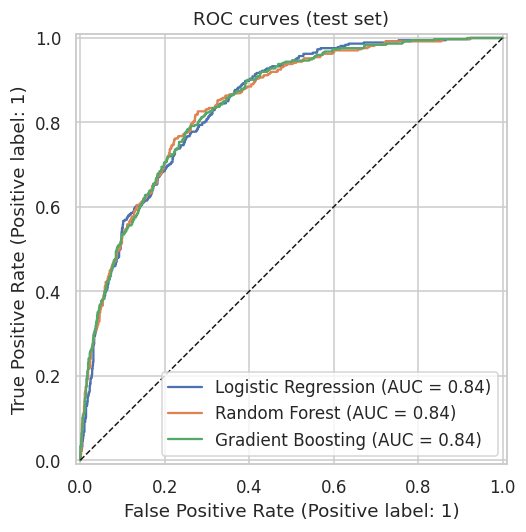

In [8]:
fig, ax = plt.subplots(figsize=(6.5,5))
for name, pipe in fitted.items(): RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title("ROC curves (test set)")
plt.tight_layout(); plt.savefig("images/roc_curves.png", bbox_inches="tight"); plt.show()

Selected model (best F1 — balances catching churners vs. false alarms): Random Forest


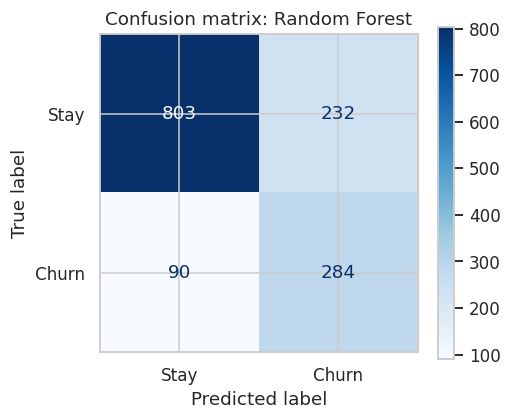

              precision    recall  f1-score   support

        Stay       0.90      0.78      0.83      1035
       Churn       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [9]:
best_name = results["F1"].idxmax(); best = fitted[best_name]; print("Selected model (best F1 — balances catching churners vs. false alarms):", best_name)
fig, ax = plt.subplots(figsize=(4.8,4))
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, display_labels=["Stay","Churn"], cmap="Blues", ax=ax)
ax.set_title(f"Confusion matrix: {best_name}"); plt.tight_layout(); plt.savefig("images/confusion_matrix.png", bbox_inches="tight"); plt.show()
print(classification_report(y_test, best.predict(X_test), target_names=["Stay","Churn"]))

## 5. What drives churn? (Logistic Regression coefficients)

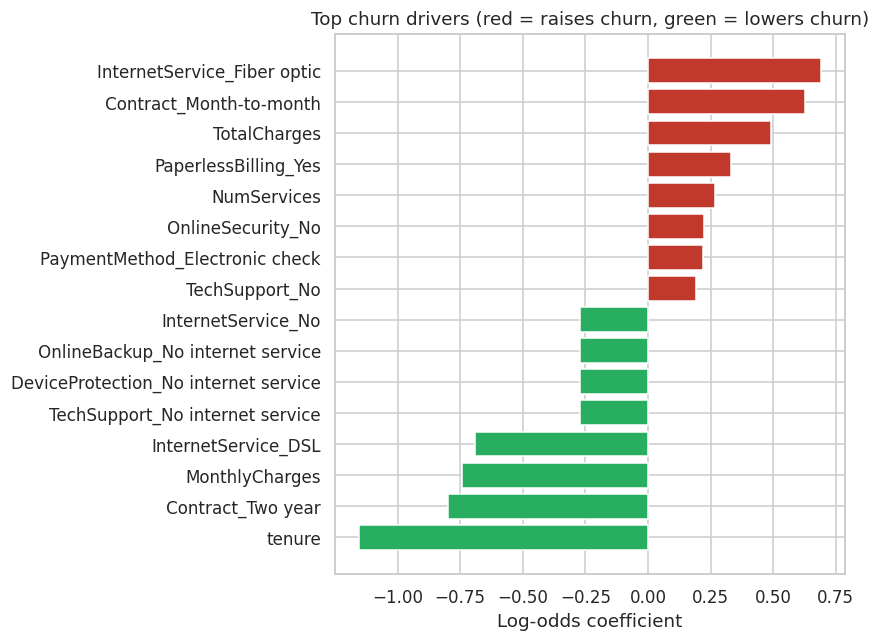

In [10]:
lr = fitted["Logistic Regression"]
names = lr.named_steps["pre"].get_feature_names_out()
coef = pd.Series(lr.named_steps["model"].coef_[0], index=[n.split("__",1)[1] for n in names]).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top.index, top.values, color=["#27AE60" if v<0 else "#C0392B" for v in top.values])
ax.set_title("Top churn drivers (red = raises churn, green = lowers churn)"); ax.set_xlabel("Log-odds coefficient")
plt.tight_layout(); plt.savefig("images/churn_drivers.png", bbox_inches="tight"); plt.show()

## 6. Business impact: scoring and prioritising at-risk customers

In [11]:
test = X_test.copy(); test["churn_prob"] = best.predict_proba(X_test)[:,1]; test["actual"] = y_test.values
test["risk_tier"] = pd.cut(test.churn_prob, [0,0.3,0.6,1], labels=["Low","Medium","High"], include_lowest=True)
tier = test.groupby("risk_tier", observed=True).agg(customers=("actual","size"), actual_churn_rate=("actual","mean"), monthly_revenue=("MonthlyCharges","sum"))
tier["actual_churn_rate"] = (tier.actual_churn_rate*100).round(1)
top_decile = test.nlargest(int(len(test)*0.2), "churn_prob")
print(f"Top 20% highest-risk customers capture {top_decile.actual.sum()/test.actual.sum():.0%} of all churners in the test set.")
tier

Top 20% highest-risk customers capture 50% of all churners in the test set.


,customers,actual_churn_rate,monthly_revenue
risk_tier,,,
Low,679,6.6,36149.95
Medium,320,28.7,22688.50
High,410,57.8,31462.75


In [12]:
joblib.dump(best, "models/churn_model.joblib", compress=3); print("Saved models/churn_model.joblib")

Saved models/churn_model.joblib


## 7. Conclusions & recommendations
- **Contract type is the strongest signal.** Month-to-month customers churn far more than those on 1- or 2-year contracts. *Action:* offer discounts or perks for switching to annual plans.
- **The first 12 months are the danger zone.** *Action:* an onboarding programme with check-ins at months 1, 3 and 6.
- **Fiber optic and electronic-check customers churn more.** *Action:* look into fiber service quality and pricing, and nudge customers towards auto-pay.
- **Tech Support and Online Security lower churn.** *Action:* bundle them free for the first 6 months for high-risk new customers.
- The model's **risk tiers** tell the retention team where to spend: most actual churners sit in the High tier, so it can call a small, targeted list instead of everyone.